## Introducing EDA on the Day dataset

In [ ]:
# Import pandas, numpy, matplotlib, and seaborn for data handling and plotting.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load the day-level bike sharing data from day.csv into df.
df=pd.read_csv('day.csv')

In [ ]:
#Preview the first few rows of df.
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [ ]:
# Preview the last few rows of df.
df.tail()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796
730,731,2012-12-31,1,1,12,0,1,1,2,0.215833,0.223487,0.577500,0.154846,439,2290,2729


In [ ]:
#Check dataset dimensions (rows, columns).
df.shape

(731, 16)

In [ ]:
# Inspect data types of all columns.
df.dtypes

instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

In [ ]:
#Count missing values per column.
df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [ ]:
#Check for duplicated rows.
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
726    False
727    False
728    False
729    False
730    False
Length: 731, dtype: bool

#  DATA PREPROCESSING

In [ ]:

# Convert date column to datetime
df['dteday'] = pd.to_datetime(df['dteday'])

# Extract additional time features
df['year'] = df['dteday']. dt.year
df['month'] = df['dteday'].dt.month
df['day'] = df['dteday'].dt. day
df['day_of_week'] = df['dteday'].dt.dayofweek

# Create meaningful labels for categorical variables
season_labels = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_labels = {1: 'Clear', 2: 'Mist', 3: 'Light Snow/Rain', 4: 'Heavy Rain/Snow'}
weekday_labels = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday',
                  4: 'Friday', 5: 'Saturday', 6: 'Sunday'}

df['season_label'] = df['season'].map(season_labels)
df['weather_label'] = df['weathersit'].map(weather_labels)
df['weekday_label'] = df['weekday'].map(weekday_labels)
df['year_label'] = df['yr'].map({0: '2011', 1: '2012'})

print("Data preprocessing completed!")

Data preprocessing completed!


# Exploratory Data Analysis on Day dataset

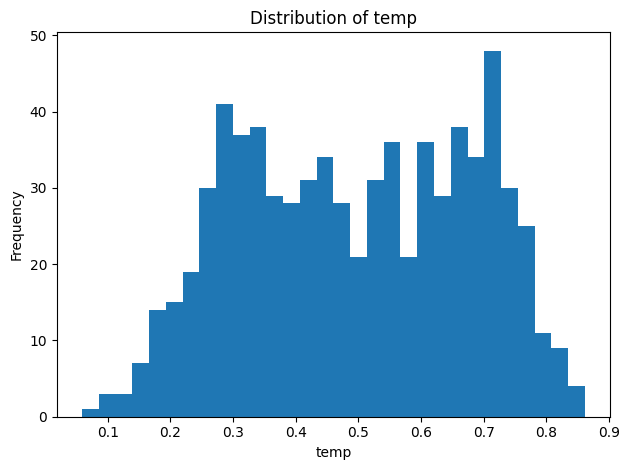

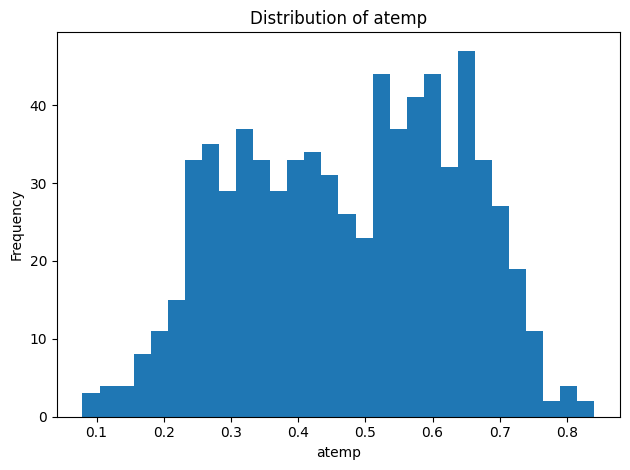

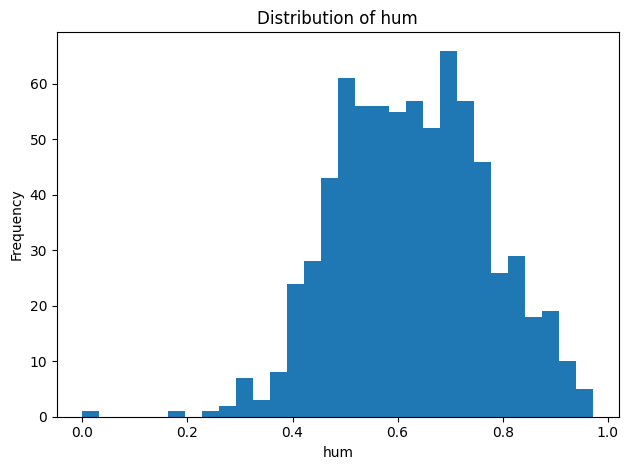

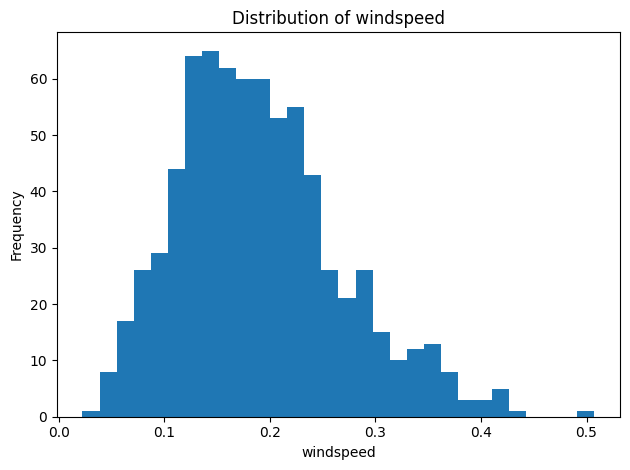

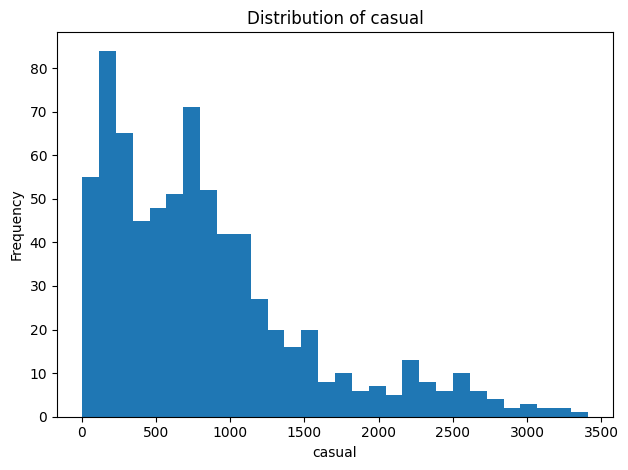

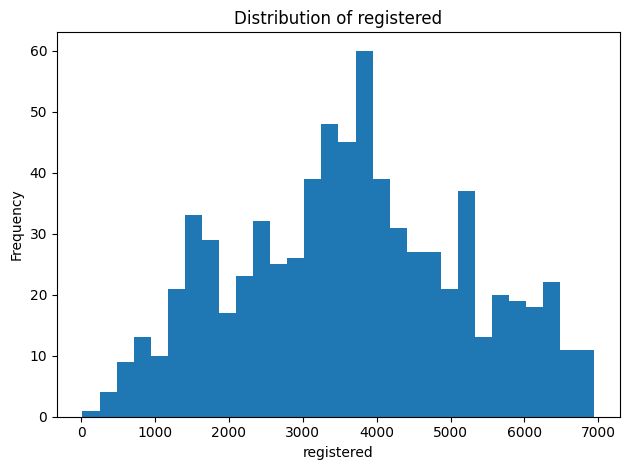

In [ ]:
#Plot histograms for key numeric columns to inspect distributions.
numeric_cols = ['temp','atemp','hum','windspeed','casual','registered']

for col in numeric_cols:
    plt.figure()
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

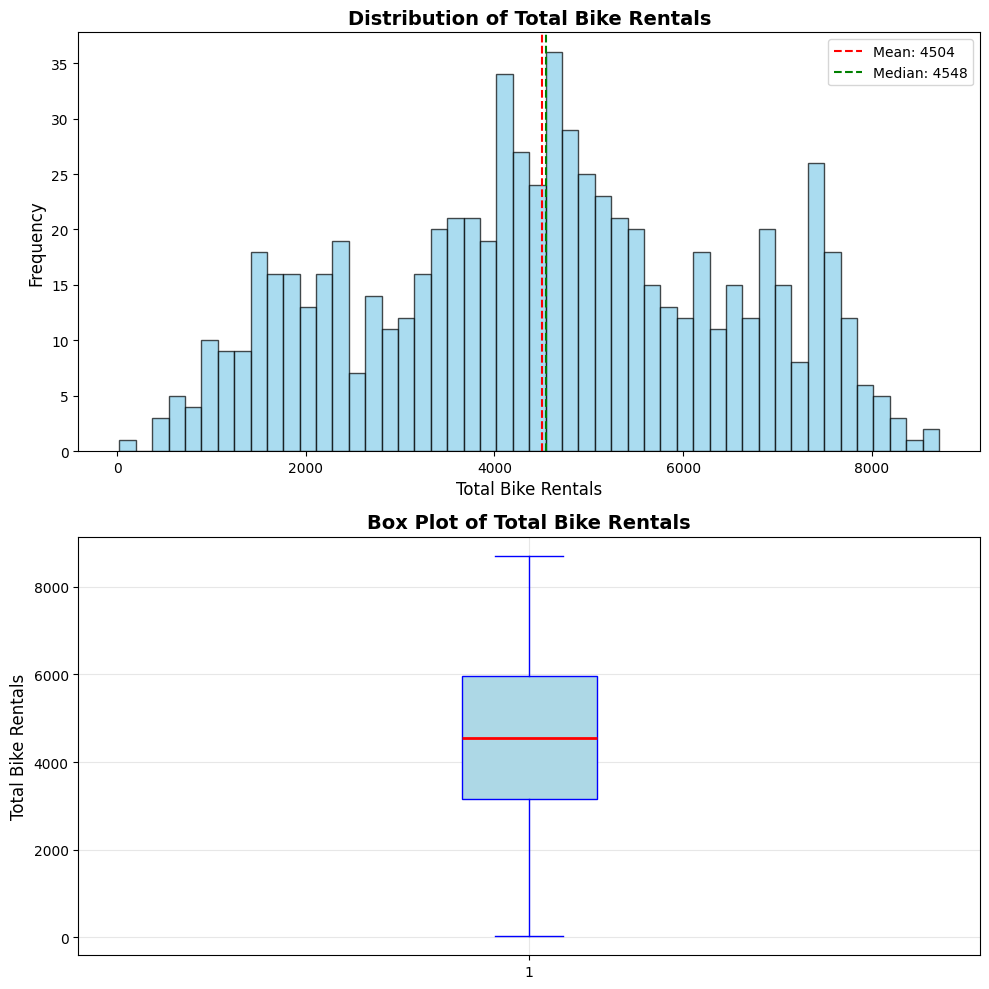

In [ ]:
# Distribution of Target Variable (Total Bike Rentals)
fig, axes = plt.subplots(2, 1, figsize=(10, 10))  # 2 rows, 1 column

# ----------------- 1️⃣ Histogram -----------------
axes[0].hist(df['cnt'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Total Bike Rentals', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Total Bike Rentals', fontsize=14, fontweight='bold')
axes[0].axvline(df['cnt'].mean(), color='red', linestyle='--', label=f'Mean: {df["cnt"].mean():.0f}')
axes[0].axvline(df['cnt'].median(), color='green', linestyle='--', label=f'Median: {df["cnt"].median():.0f}')
axes[0].legend()

# ----------------- 2️⃣ Box Plot -----------------
axes[1].boxplot(
    df['cnt'], vert=True, patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='blue'),
    whiskerprops=dict(color='blue'),
    capprops=dict(color='blue'),
    medianprops=dict(color='red', linewidth=2)
)
axes[1].set_ylabel('Total Bike Rentals', fontsize=12)
axes[1].set_title('Box Plot of Total Bike Rentals', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


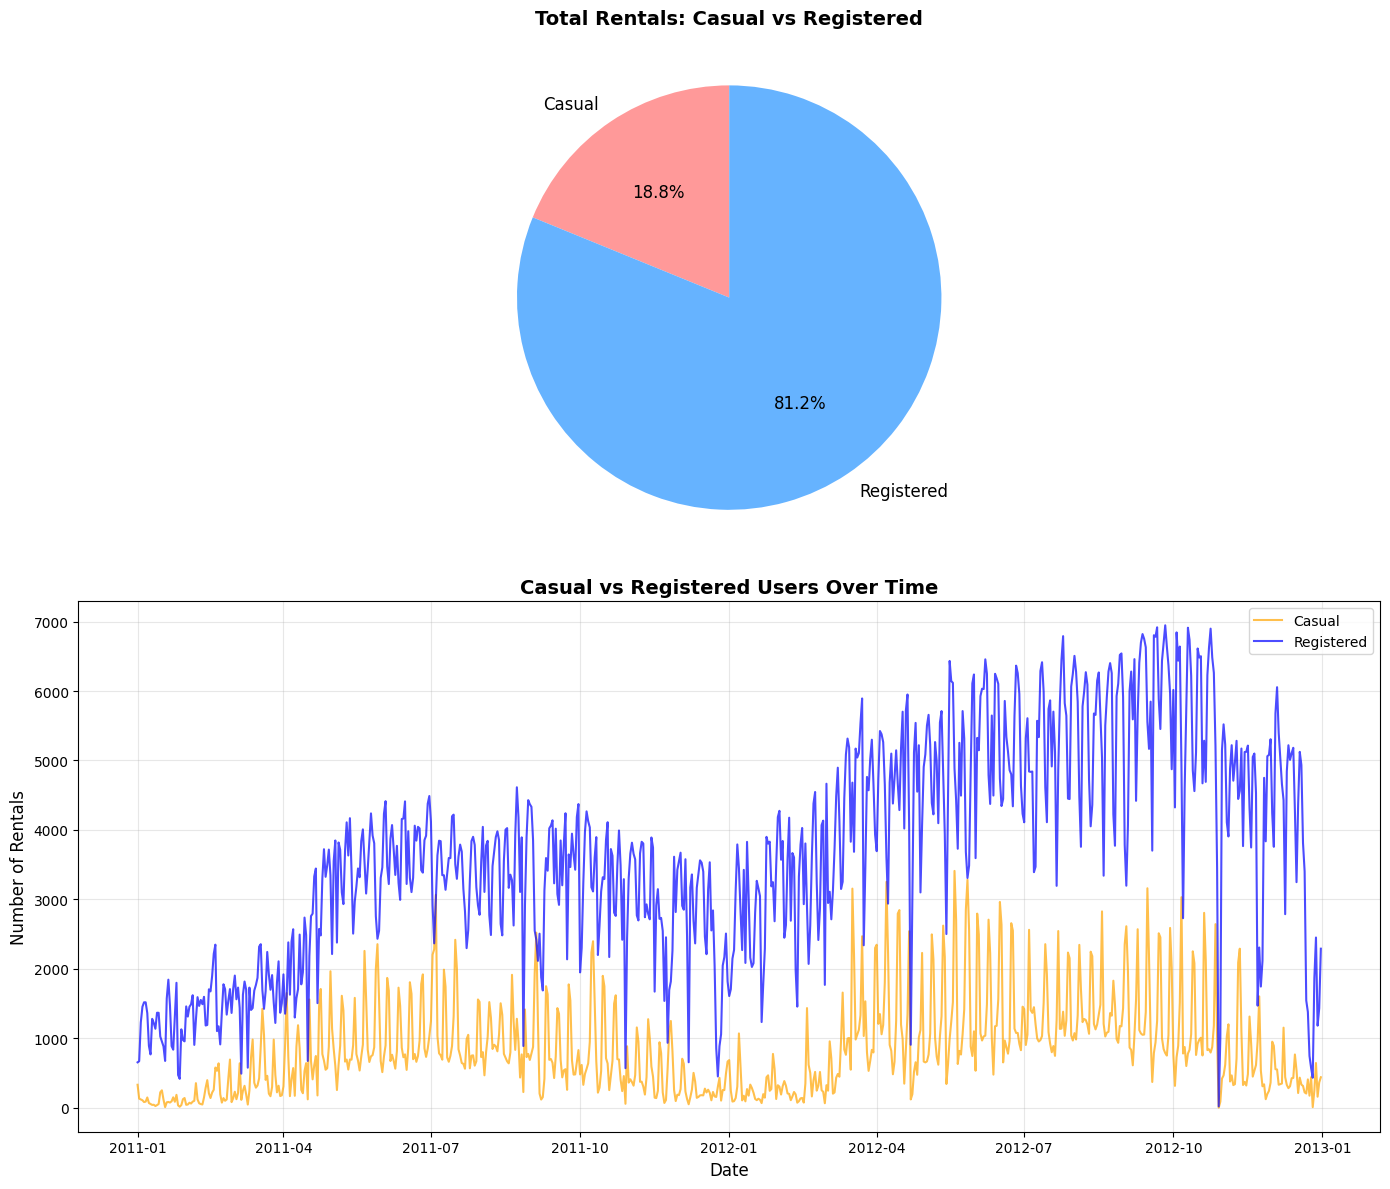

In [ ]:
# Compare casual vs registered rentals via pie chart and time-series lines.
fig, axes = plt.subplots(2, 1, figsize=(14, 12))  # Changed to 2 rows

# ----------------- 1️⃣ Pie Chart -----------------
user_totals = [df['casual'].sum(), df['registered'].sum()]
colors = ['#ff9999', '#66b3ff']

axes[0].pie(
    user_totals,
    labels=['Casual', 'Registered'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 12}
)
axes[0].set_title('Total Rentals: Casual vs Registered', fontsize=14, fontweight='bold')

# ----------------- 2️⃣ Time Series Plot -----------------
axes[1].plot(df['dteday'], df['casual'], label='Casual', color='orange', alpha=0.7)
axes[1].plot(df['dteday'], df['registered'], label='Registered', color='blue', alpha=0.7)

axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Number of Rentals', fontsize=12)
axes[1].set_title('Casual vs Registered Users Over Time', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


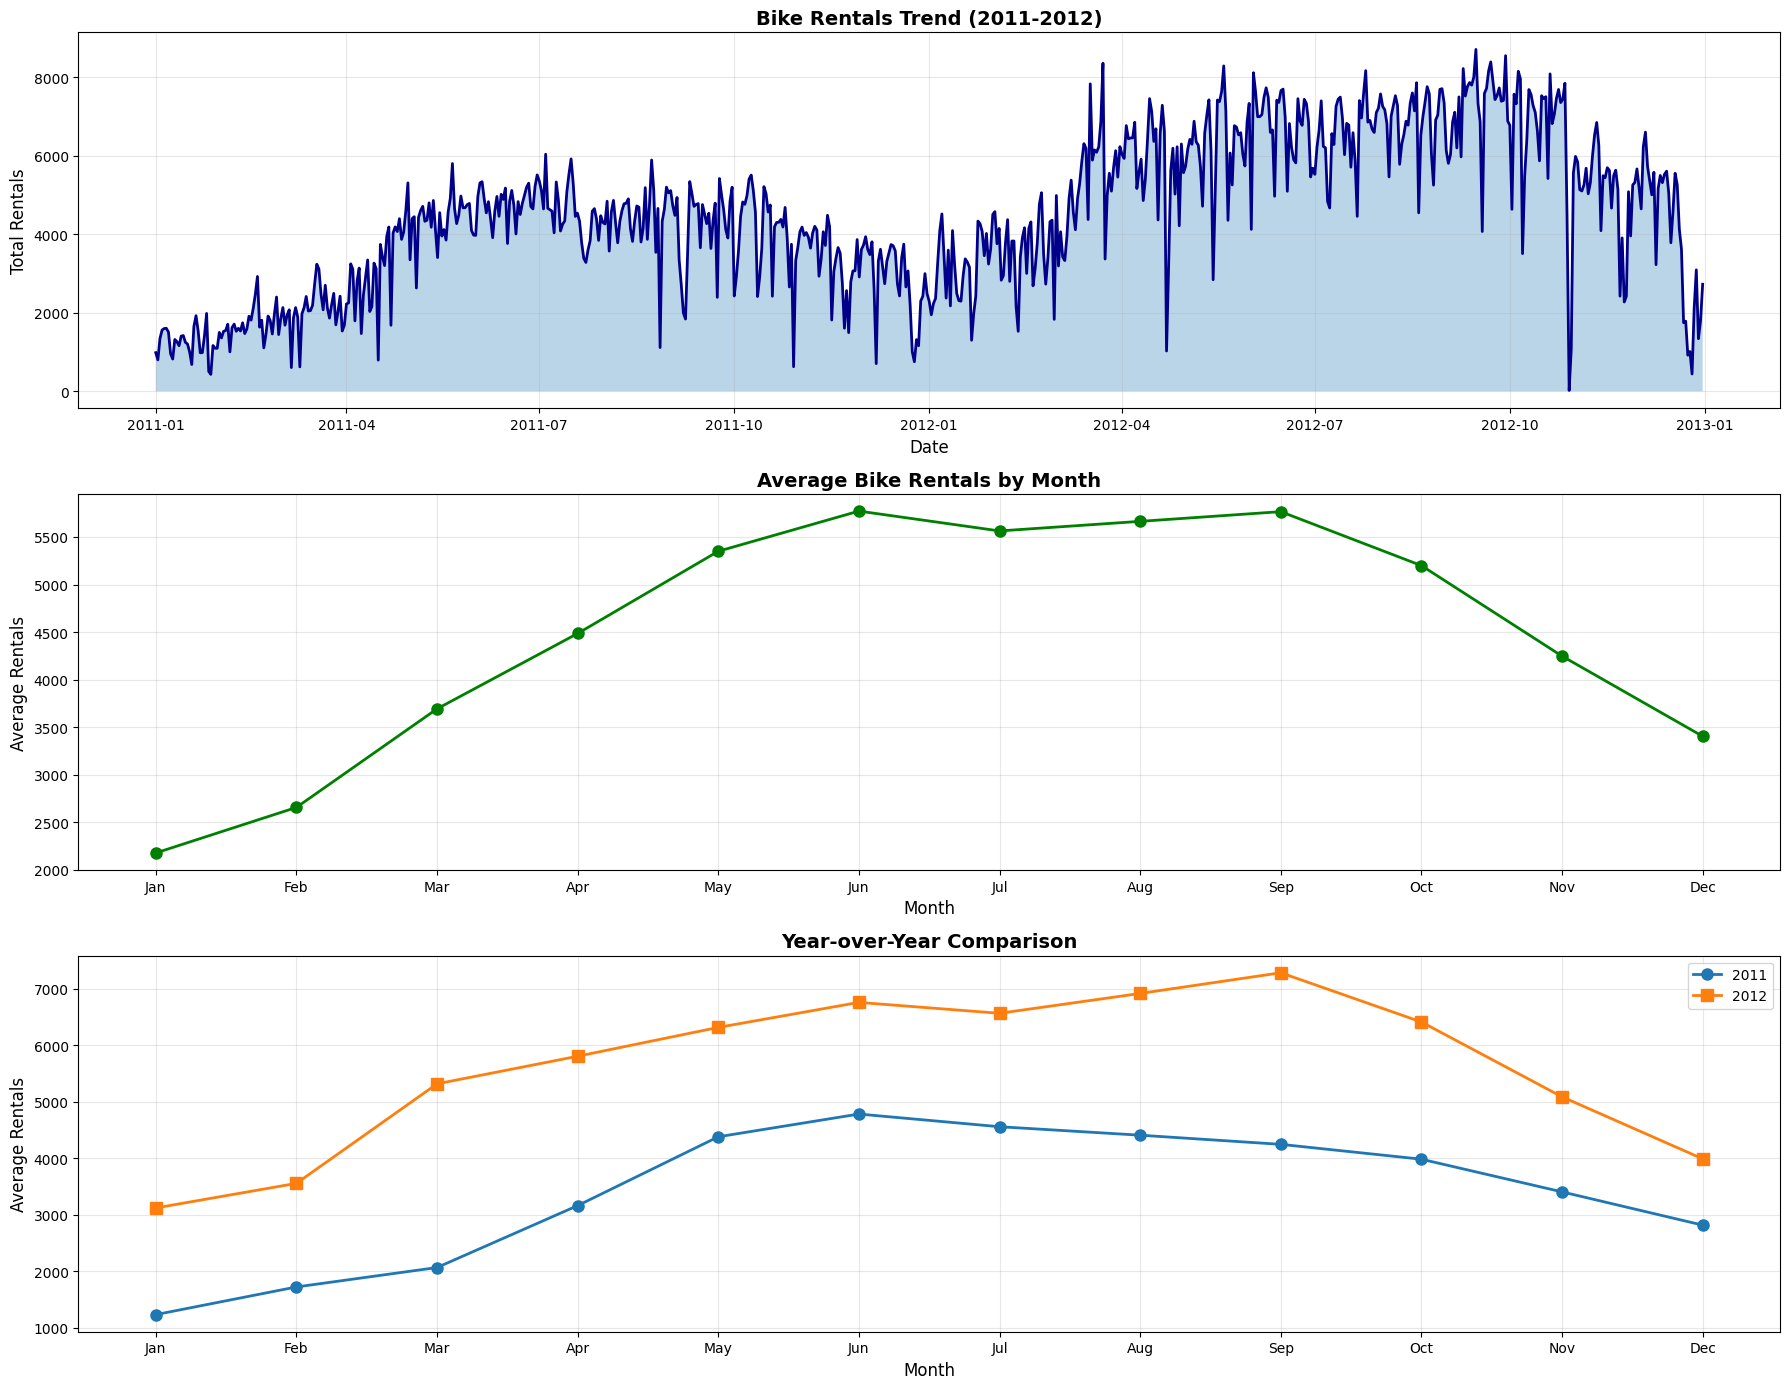

In [ ]:
# Show overall, monthly, and year-over-year rental trends in time-series plots.
fig, axes = plt.subplots(3, 1, figsize=(18, 14))

# Overall trend
axes[0].plot(df['dteday'], df['cnt'], color='darkblue', linewidth=2)
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('Total Rentals', fontsize=12)
axes[0].set_title('Bike Rentals Trend (2011-2012)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].fill_between(df['dteday'], df['cnt'], alpha=0.3)

# Monthly average
monthly_avg = df.groupby('month')['cnt'].mean()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[1].plot(range(1, 13), monthly_avg.values, marker='o', linewidth=2, markersize=8, color='green')
axes[1].set_xlabel('Month', fontsize=12)
axes[1].set_ylabel('Average Rentals', fontsize=12)
axes[1].set_title('Average Bike Rentals by Month', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(months)
axes[1].grid(True, alpha=0.3)

# Year comparison
yearly_comparison = df.groupby(['month', 'year_label'])['cnt'].mean().unstack()
axes[2].plot(range(1, 13), yearly_comparison['2011'].values, marker='o', label='2011', linewidth=2, markersize=8)
axes[2].plot(range(1, 13), yearly_comparison['2012'].values, marker='s', label='2012', linewidth=2, markersize=8)
axes[2].set_xlabel('Month', fontsize=12)
axes[2].set_ylabel('Average Rentals', fontsize=12)
axes[2].set_title('Year-over-Year Comparison', fontsize=14, fontweight='bold')
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(months)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import warnings
warnings.filterwarnings('ignore')


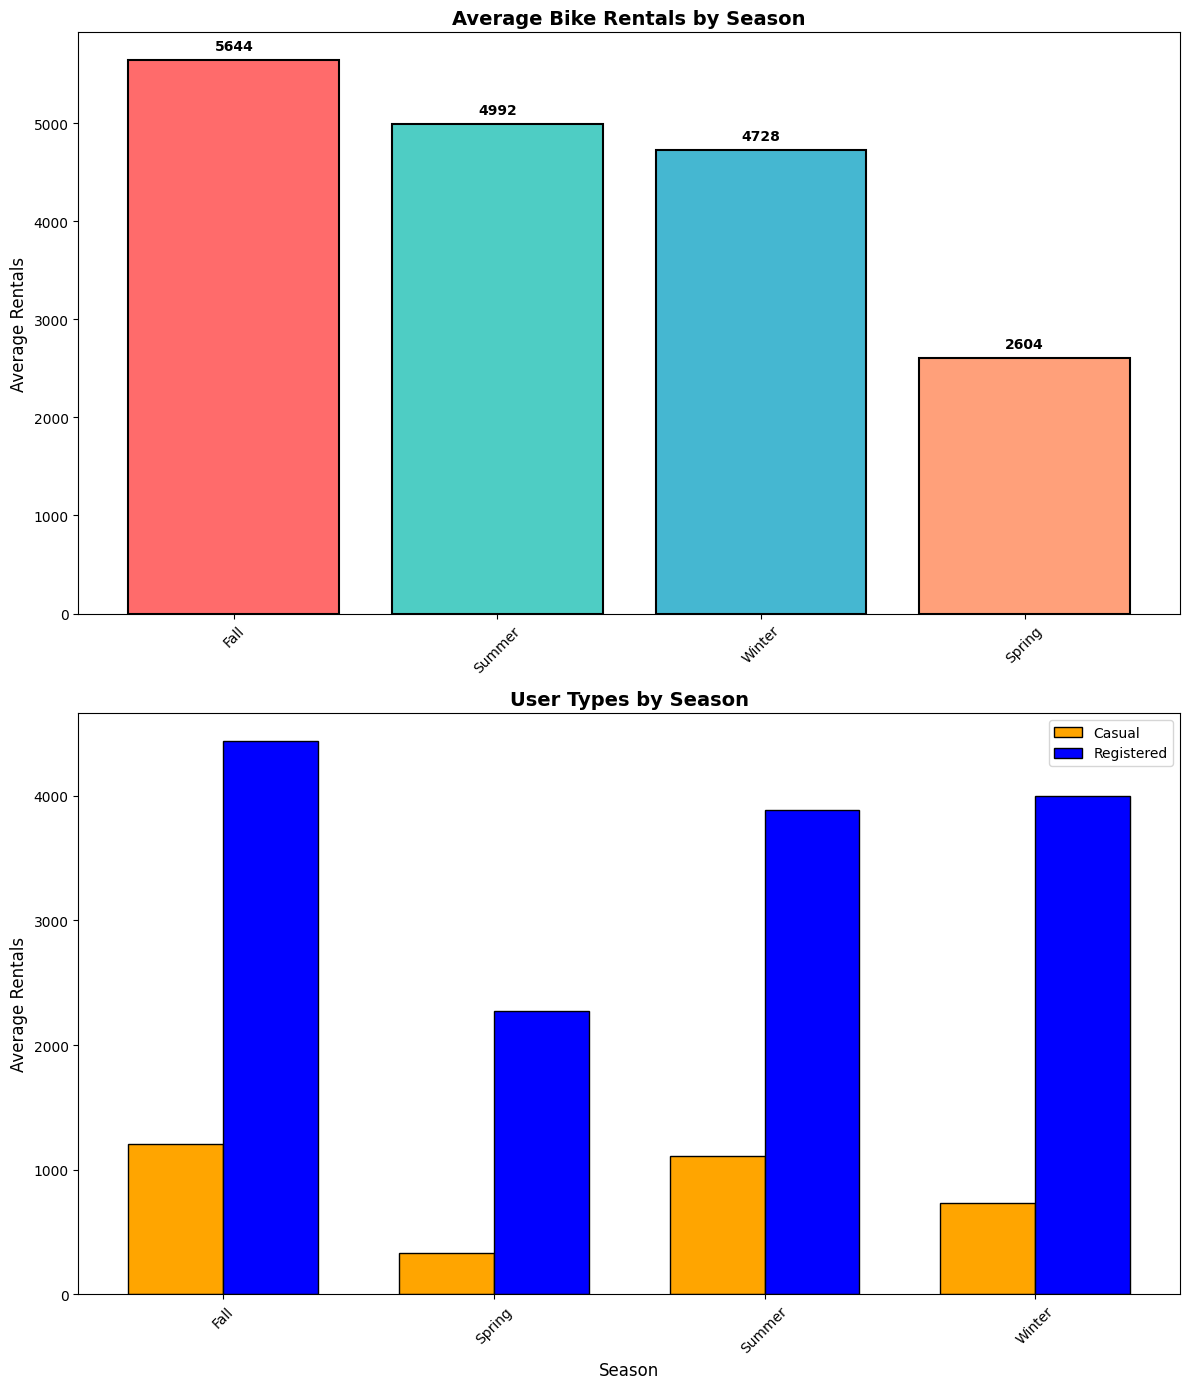

In [ ]:
# Compare seasonal rental averages and casual vs registered by season
fig, axes = plt.subplots(2, 1, figsize=(12, 14))  # Only 2 rows now

# 1️⃣ Bar plot - Average rentals by season
season_avg = df.groupby('season_label')['cnt'].mean().sort_values(ascending=False)
colors_season = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

axes[0].bar(season_avg.index, season_avg.values, color=colors_season, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Average Rentals', fontsize=12)
axes[0].set_title('Average Bike Rentals by Season', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

for i, v in enumerate(season_avg.values):
    axes[0].text(i, v + 100, f'{v:.0f}', ha='center', fontsize=10, fontweight='bold')

# 2️⃣ Casual vs Registered by season
season_users = df.groupby('season_label')[['casual', 'registered']].mean()
x = np.arange(len(season_users.index))
width = 0.35

axes[1].bar(x - width/2, season_users['casual'], width, label='Casual',
            color='orange', edgecolor='black')
axes[1].bar(x + width/2, season_users['registered'], width, label='Registered',
            color='blue', edgecolor='black')

axes[1].set_xlabel('Season', fontsize=12)
axes[1].set_ylabel('Average Rentals', fontsize=12)
axes[1].set_title('User Types by Season', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(season_users.index, rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()


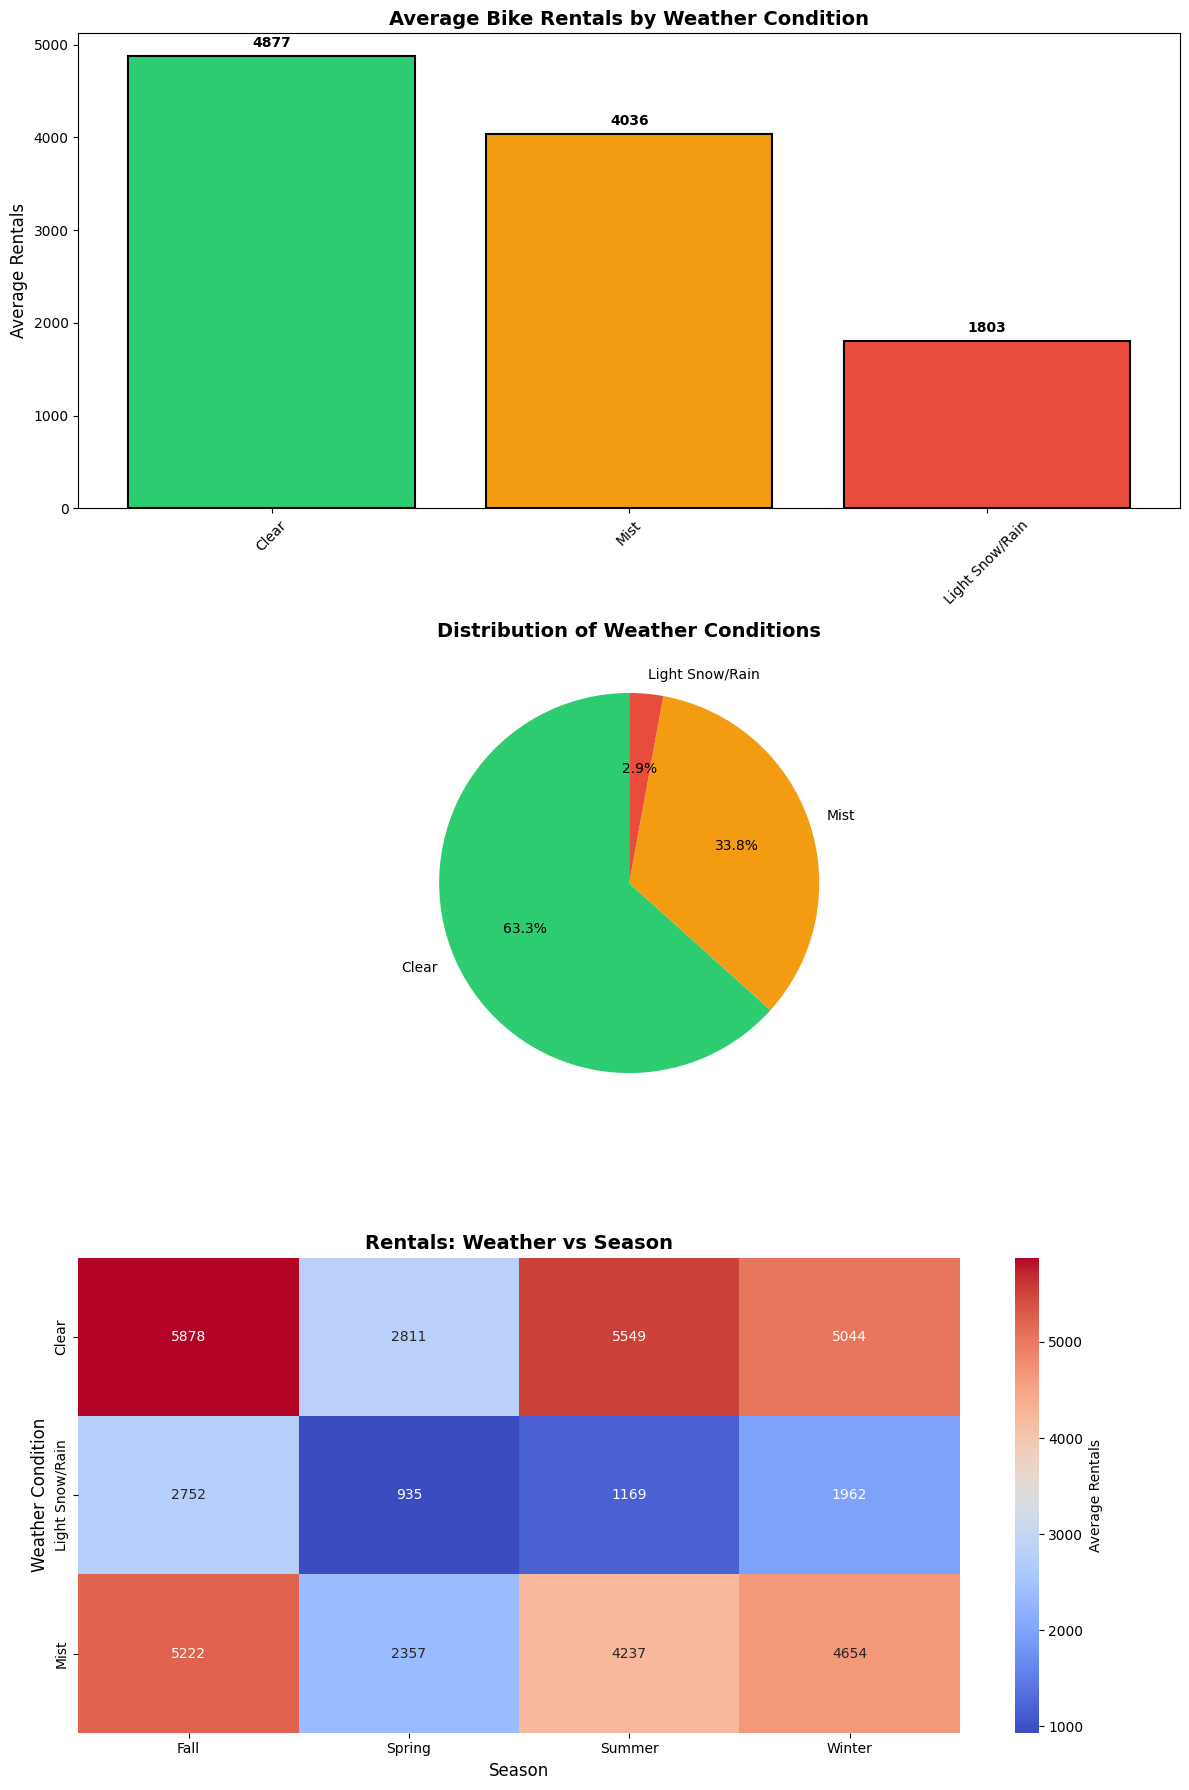

In [ ]:
#  Assess rental levels by weather, weather frequency, and weather-season heatmap.
fig, axes = plt.subplots(3, 1, figsize=(12, 18))  # 3 plots stacked vertically

# 1️⃣ Bar plot - Rentals by weather
weather_avg = df.groupby('weather_label')['cnt'].mean().sort_values(ascending=False)
colors_weather = ['#2ECC71', '#F39C12', '#E74C3C', '#8E44AD']
axes[0].bar(weather_avg.index, weather_avg.values, color=colors_weather, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Average Rentals', fontsize=12)
axes[0].set_title('Average Bike Rentals by Weather Condition', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(weather_avg.values):
    axes[0].text(i, v + 100, f'{v:.0f}', ha='center', fontsize=10, fontweight='bold')

# 2️⃣ Pie chart - Weather situation count
weather_count = df['weather_label'].value_counts()
axes[1].pie(weather_count.values, labels=weather_count.index, autopct='%1.1f%%',
            colors=colors_weather, startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Distribution of Weather Conditions', fontsize=14, fontweight='bold')

# 3️⃣ Heatmap - Weather vs Season
weather_season = df.pivot_table(values='cnt', index='weather_label', columns='season_label', aggfunc='mean')
sns.heatmap(weather_season, annot=True, fmt='.0f', cmap='coolwarm', ax=axes[2],
            cbar_kws={'label': 'Average Rentals'})
axes[2].set_xlabel('Season', fontsize=12)
axes[2].set_ylabel('Weather Condition', fontsize=12)
axes[2].set_title('Rentals: Weather vs Season', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


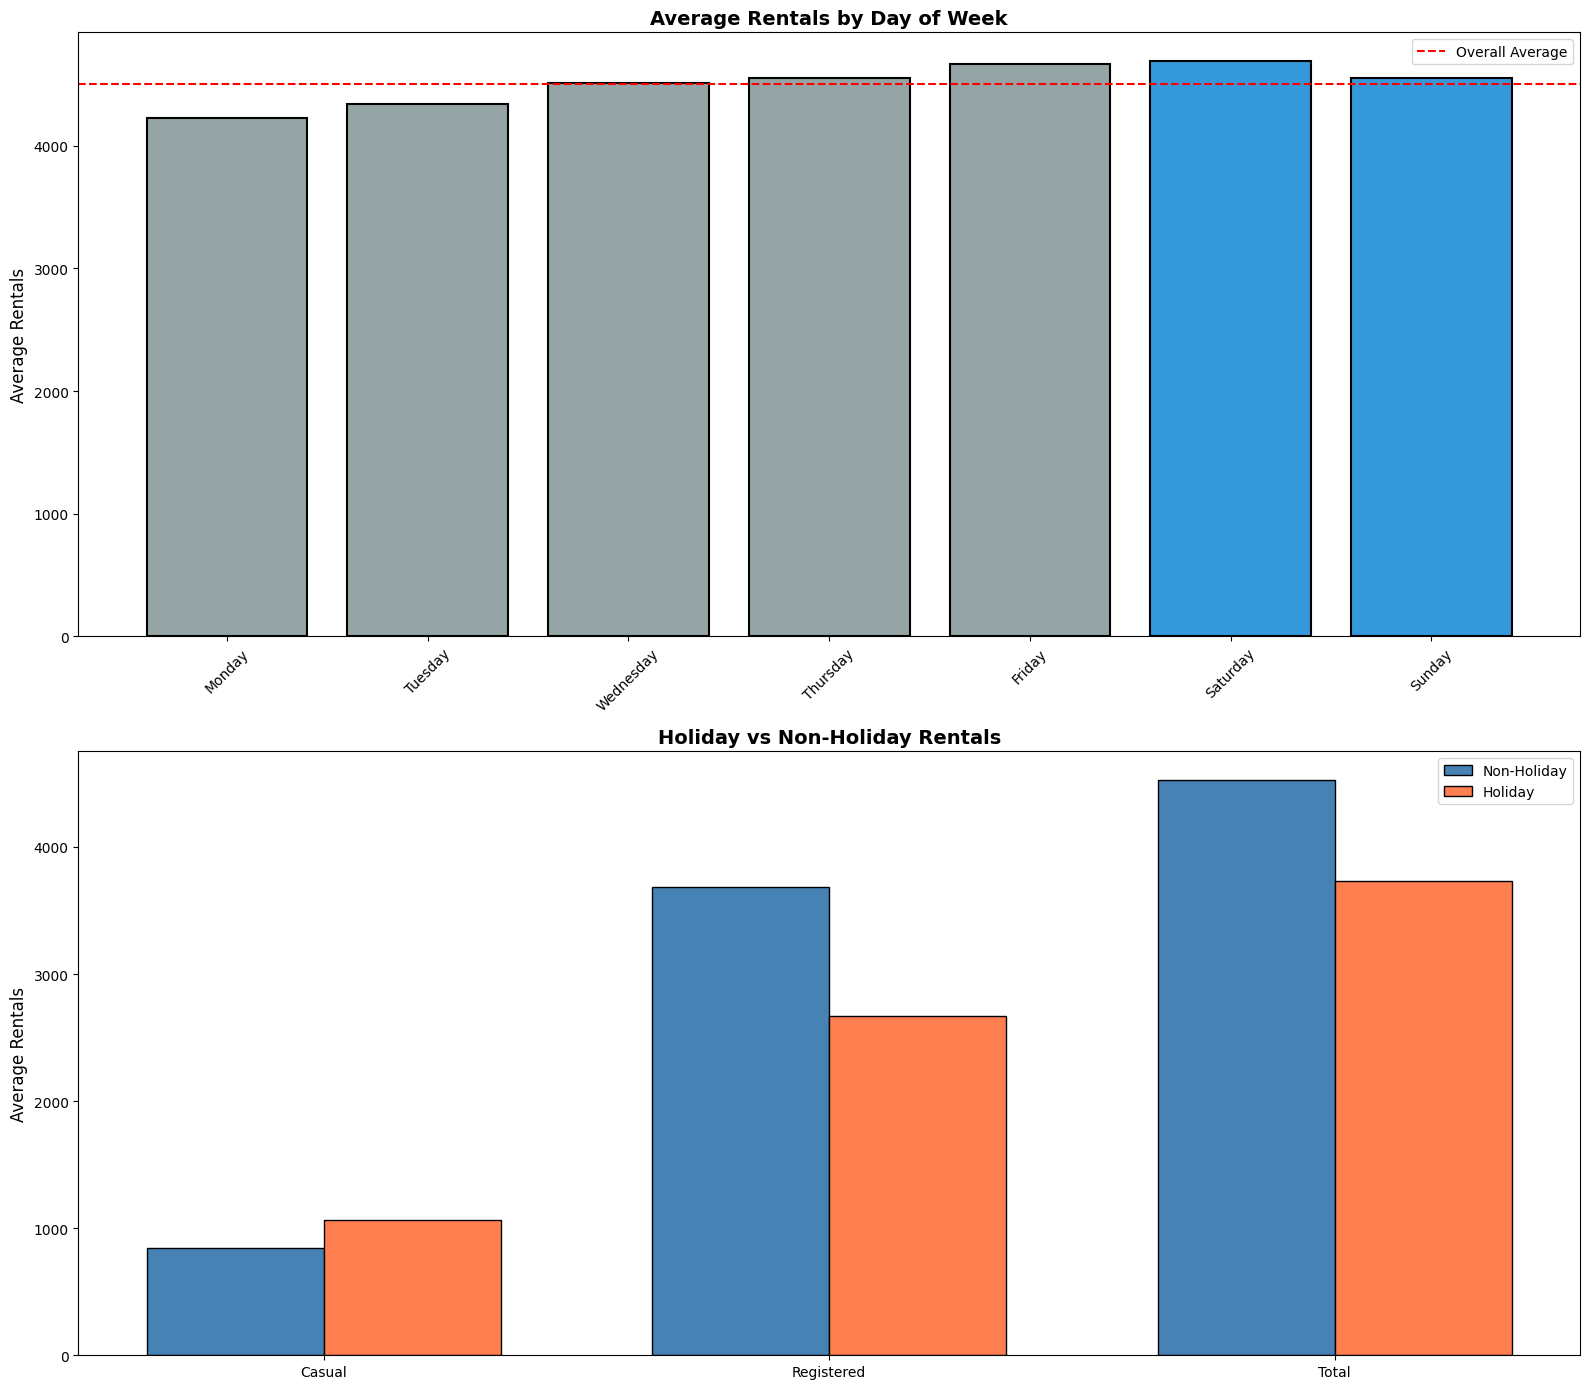

In [ ]:
#Compare rentals by weekday and by holiday vs non-holiday.
fig, axes = plt.subplots(2, 1, figsize=(16, 14))

# -------------------------------------------------------
# 1️⃣ Average Rentals by Day of Week
# -------------------------------------------------------
weekday_avg = df.groupby('weekday_label')['cnt'].mean()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_avg = weekday_avg.reindex(weekday_order)

colors_week = ['#3498db' if day in ['Saturday', 'Sunday'] else '#95a5a6' for day in weekday_order]

axes[0].bar(weekday_order, weekday_avg.values,
            color=colors_week, edgecolor='black', linewidth=1.5)

axes[0].set_ylabel('Average Rentals', fontsize=12)
axes[0].set_title('Average Rentals by Day of Week', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

axes[0].axhline(y=weekday_avg.mean(), color='r', linestyle='--', label='Overall Average')
axes[0].legend()

# -------------------------------------------------------
# 2️⃣ Holiday vs Non-Holiday Rentals
# -------------------------------------------------------
holiday_comparison = df.groupby('holiday')[['casual', 'registered', 'cnt']].mean()

x = np.arange(len(holiday_comparison.columns))
width = 0.35

axes[1].bar(x - width/2, holiday_comparison.loc[0], width,
            label='Non-Holiday', color='steelblue', edgecolor='black')

axes[1].bar(x + width/2, holiday_comparison.loc[1], width,
            label='Holiday', color='coral', edgecolor='black')

axes[1].set_ylabel('Average Rentals', fontsize=12)
axes[1].set_title('Holiday vs Non-Holiday Rentals', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Casual', 'Registered', 'Total'])
axes[1].legend()

plt.tight_layout()
plt.show()


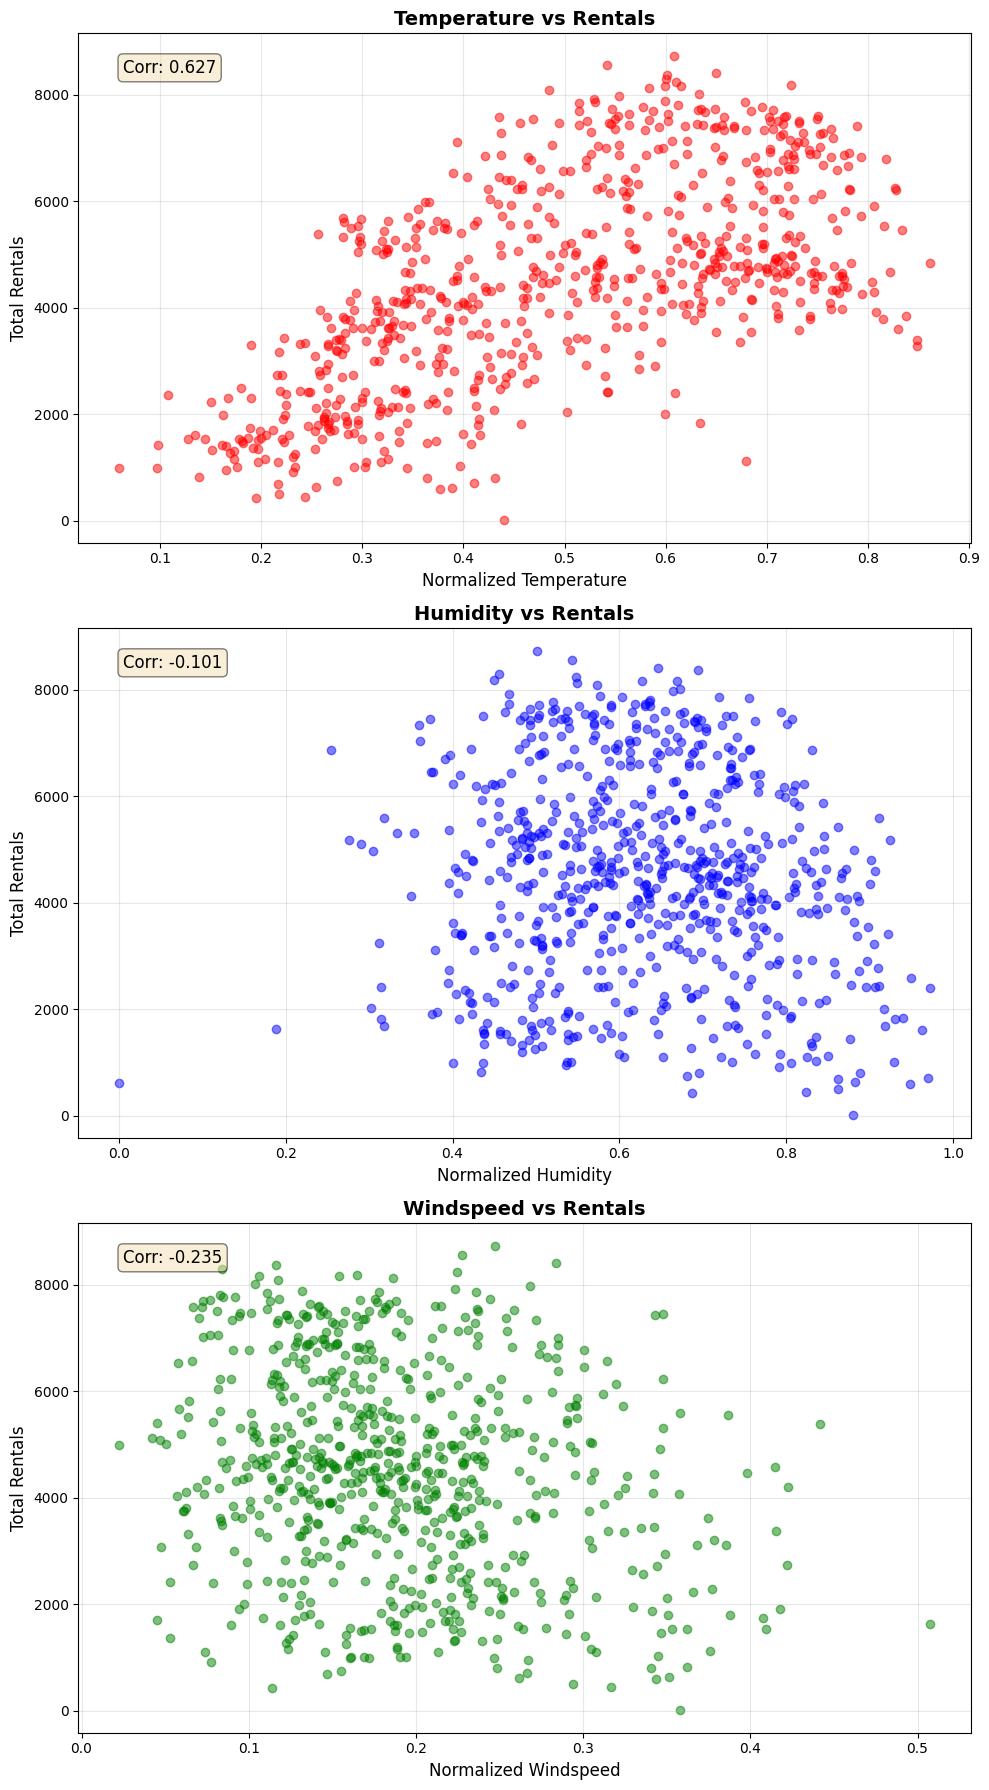

In [ ]:
#Scatter plots and correlations of rentals vs temperature, humidity, and windspeed.
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

# Temperature scatter plot
axes[0].scatter(df['temp'], df['cnt'], alpha=0.5, color='red')
axes[0].set_xlabel('Normalized Temperature', fontsize=12)
axes[0].set_ylabel('Total Rentals', fontsize=12)
axes[0].set_title('Temperature vs Rentals', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
temp_corr = df['temp'].corr(df['cnt'])
axes[0].text(0.05, 0.95, f'Corr: {temp_corr:.3f}', transform=axes[0].transAxes,
             fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Humidity scatter plot
axes[1].scatter(df['hum'], df['cnt'], alpha=0.5, color='blue')
axes[1].set_xlabel('Normalized Humidity', fontsize=12)
axes[1].set_ylabel('Total Rentals', fontsize=12)
axes[1].set_title('Humidity vs Rentals', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
hum_corr = df['hum'].corr(df['cnt'])
axes[1].text(0.05, 0.95, f'Corr: {hum_corr:.3f}', transform=axes[1].transAxes,
             fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Windspeed scatter plot
axes[2].scatter(df['windspeed'], df['cnt'], alpha=0.5, color='green')
axes[2].set_xlabel('Normalized Windspeed', fontsize=12)
axes[2].set_ylabel('Total Rentals', fontsize=12)
axes[2].set_title('Windspeed vs Rentals', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)
wind_corr = df['windspeed'].corr(df['cnt'])
axes[2].text(0.05, 0.95, f'Corr: {wind_corr:.3f}', transform=axes[2].transAxes,
             fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()


In [ ]:
#  KEY EDA insights and summary statistics for the day dataset.
print("\n" + "="*80)
print("KEY INSIGHTS FROM EDA")
print("="*80)

print("\n1. OVERALL STATISTICS:")
print(f"   - Total days analyzed: {len(df)}")
print(f"   - Average daily rentals: {df['cnt']. mean():.0f}")
print(f"   - Peak day rentals: {df['cnt'].max()} on {df.loc[df['cnt'].idxmax(), 'dteday'].strftime('%Y-%m-%d')}")
print(f"   - Lowest day rentals: {df['cnt'].min()} on {df.loc[df['cnt'].idxmin(), 'dteday'].strftime('%Y-%m-%d')}")

#print("\n2. USER TYPE ANALYSIS:")
#print(f"   - Registered users: {df['registered'].sum():,.0f} ({df['registered'].sum()/(df['registered'].sum()+df['casual'].sum())*100:.1f}%)")
#print(f"   - Casual users: {df['casual']. sum():,.0f} ({df['casual'].sum()/(df['registered'].sum()+df['casual'].sum())*100:.1f}%)")

print("\n3. SEASONAL PATTERNS:")
season_avg = df.groupby('season_label')['cnt'].mean().sort_values(ascending=False)
print(f"   - Best season: {season_avg.index[0]} ({season_avg.values[0]:.0f} avg rentals)")
print(f"   - Worst season: {season_avg.index[-1]} ({season_avg.values[-1]:.0f} avg rentals)")

print("\n4. WEATHER IMPACT:")
weather_avg = df.groupby('weather_label')['cnt'].mean().sort_values(ascending=False)
print(f"   - Best weather: {weather_avg.index[0]} ({weather_avg. values[0]:.0f} avg rentals)")
print(f"   - Worst weather: {weather_avg.index[-1]} ({weather_avg.values[-1]:.0f} avg rentals)")

print("\n5. TEMPORAL PATTERNS:")
print(f"   - Best month: {df. groupby('month')['cnt'].mean().idxmax()} ({df.groupby('month')['cnt'].mean().max():.0f} avg)")
print(f"   - Best day of week: {df.groupby('weekday_label')['cnt'].mean().idxmax()}")
print(f"   - Working day avg: {df[df['workingday']==1]['cnt'].mean():.0f}")
print(f"   - Non-working day avg: {df[df['workingday']==0]['cnt'].mean():.0f}")

print("\n6. CORRELATIONS:")
print(f"   - Temperature correlation: {df['temp'].corr(df['cnt']):.3f} (Strong positive)")
print(f"   - Humidity correlation: {df['hum'].corr(df['cnt']):.3f}")
print(f"   - Windspeed correlation: {df['windspeed'].corr(df['cnt']):.3f}")

print("\n7. YEAR-OVER-YEAR GROWTH:")
growth_rate = ((df[df['yr']==1]['cnt']. sum() - df[df['yr']==0]['cnt'].sum()) /
               df[df['yr']==0]['cnt'].sum() * 100)
print(f"   - Total growth from 2011 to 2012: {growth_rate:.1f}%")

print("\n" + "="*80)


KEY INSIGHTS FROM EDA

1. OVERALL STATISTICS:
   - Total days analyzed: 731
   - Average daily rentals: 4504
   - Peak day rentals: 8714 on 2012-09-15
   - Lowest day rentals: 22 on 2012-10-29

3. SEASONAL PATTERNS:
   - Best season: Fall (5644 avg rentals)
   - Worst season: Spring (2604 avg rentals)

4. WEATHER IMPACT:
   - Best weather: Clear (4877 avg rentals)
   - Worst weather: Light Snow/Rain (1803 avg rentals)

5. TEMPORAL PATTERNS:
   - Best month: 6 (5772 avg)
   - Best day of week: Saturday
   - Working day avg: 4585
   - Non-working day avg: 4330

6. CORRELATIONS:
   - Temperature correlation: 0.627 (Strong positive)
   - Humidity correlation: -0.101
   - Windspeed correlation: -0.235

7. YEAR-OVER-YEAR GROWTH:
   - Total growth from 2011 to 2012: 64.9%



## Introducing EDA on the hour dataset

In [ ]:
# Import pandas for data manipulation and analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load the hourly data from hour.csv into df.
df_hour= pd.read_csv('hour.csv')

In [ ]:
#Check hourly dataset dimensions.
df_hour.shape

(17379, 17)

In [ ]:
#Inspect hourly dataset data types.
df_hour.dtypes

instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

In [ ]:
# Count missing values in the hourly dataset.
df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [ ]:
#Check for duplicated rows in the hourly dataset.
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
17374    False
17375    False
17376    False
17377    False
17378    False
Length: 17379, dtype: bool

# Data Preprocessing

In [ ]:

#Convert hourly dates and add labeled categorical features; confirm preprocessing.
df_hour['dteday'] = pd.to_datetime(df_hour['dteday'])

# Create meaningful labels
season_labels = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_labels = {1: 'Clear', 2: 'Mist', 3: 'Light Snow/Rain', 4: 'Heavy Rain/Snow'}
weekday_labels = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}

df_hour['season_label'] = df_hour['season'].map(season_labels)
df_hour['weather_label'] = df_hour['weathersit'].map(weather_labels)
df_hour['weekday_label'] = df_hour['weekday'].map(weekday_labels)
df_hour['year_label'] = df_hour['yr'].map({0: '2011', 1: '2012'})

print("✓ Data preprocessing completed!")

✓ Data preprocessing completed!


# Exploratory Data Analysis on Hour dataset

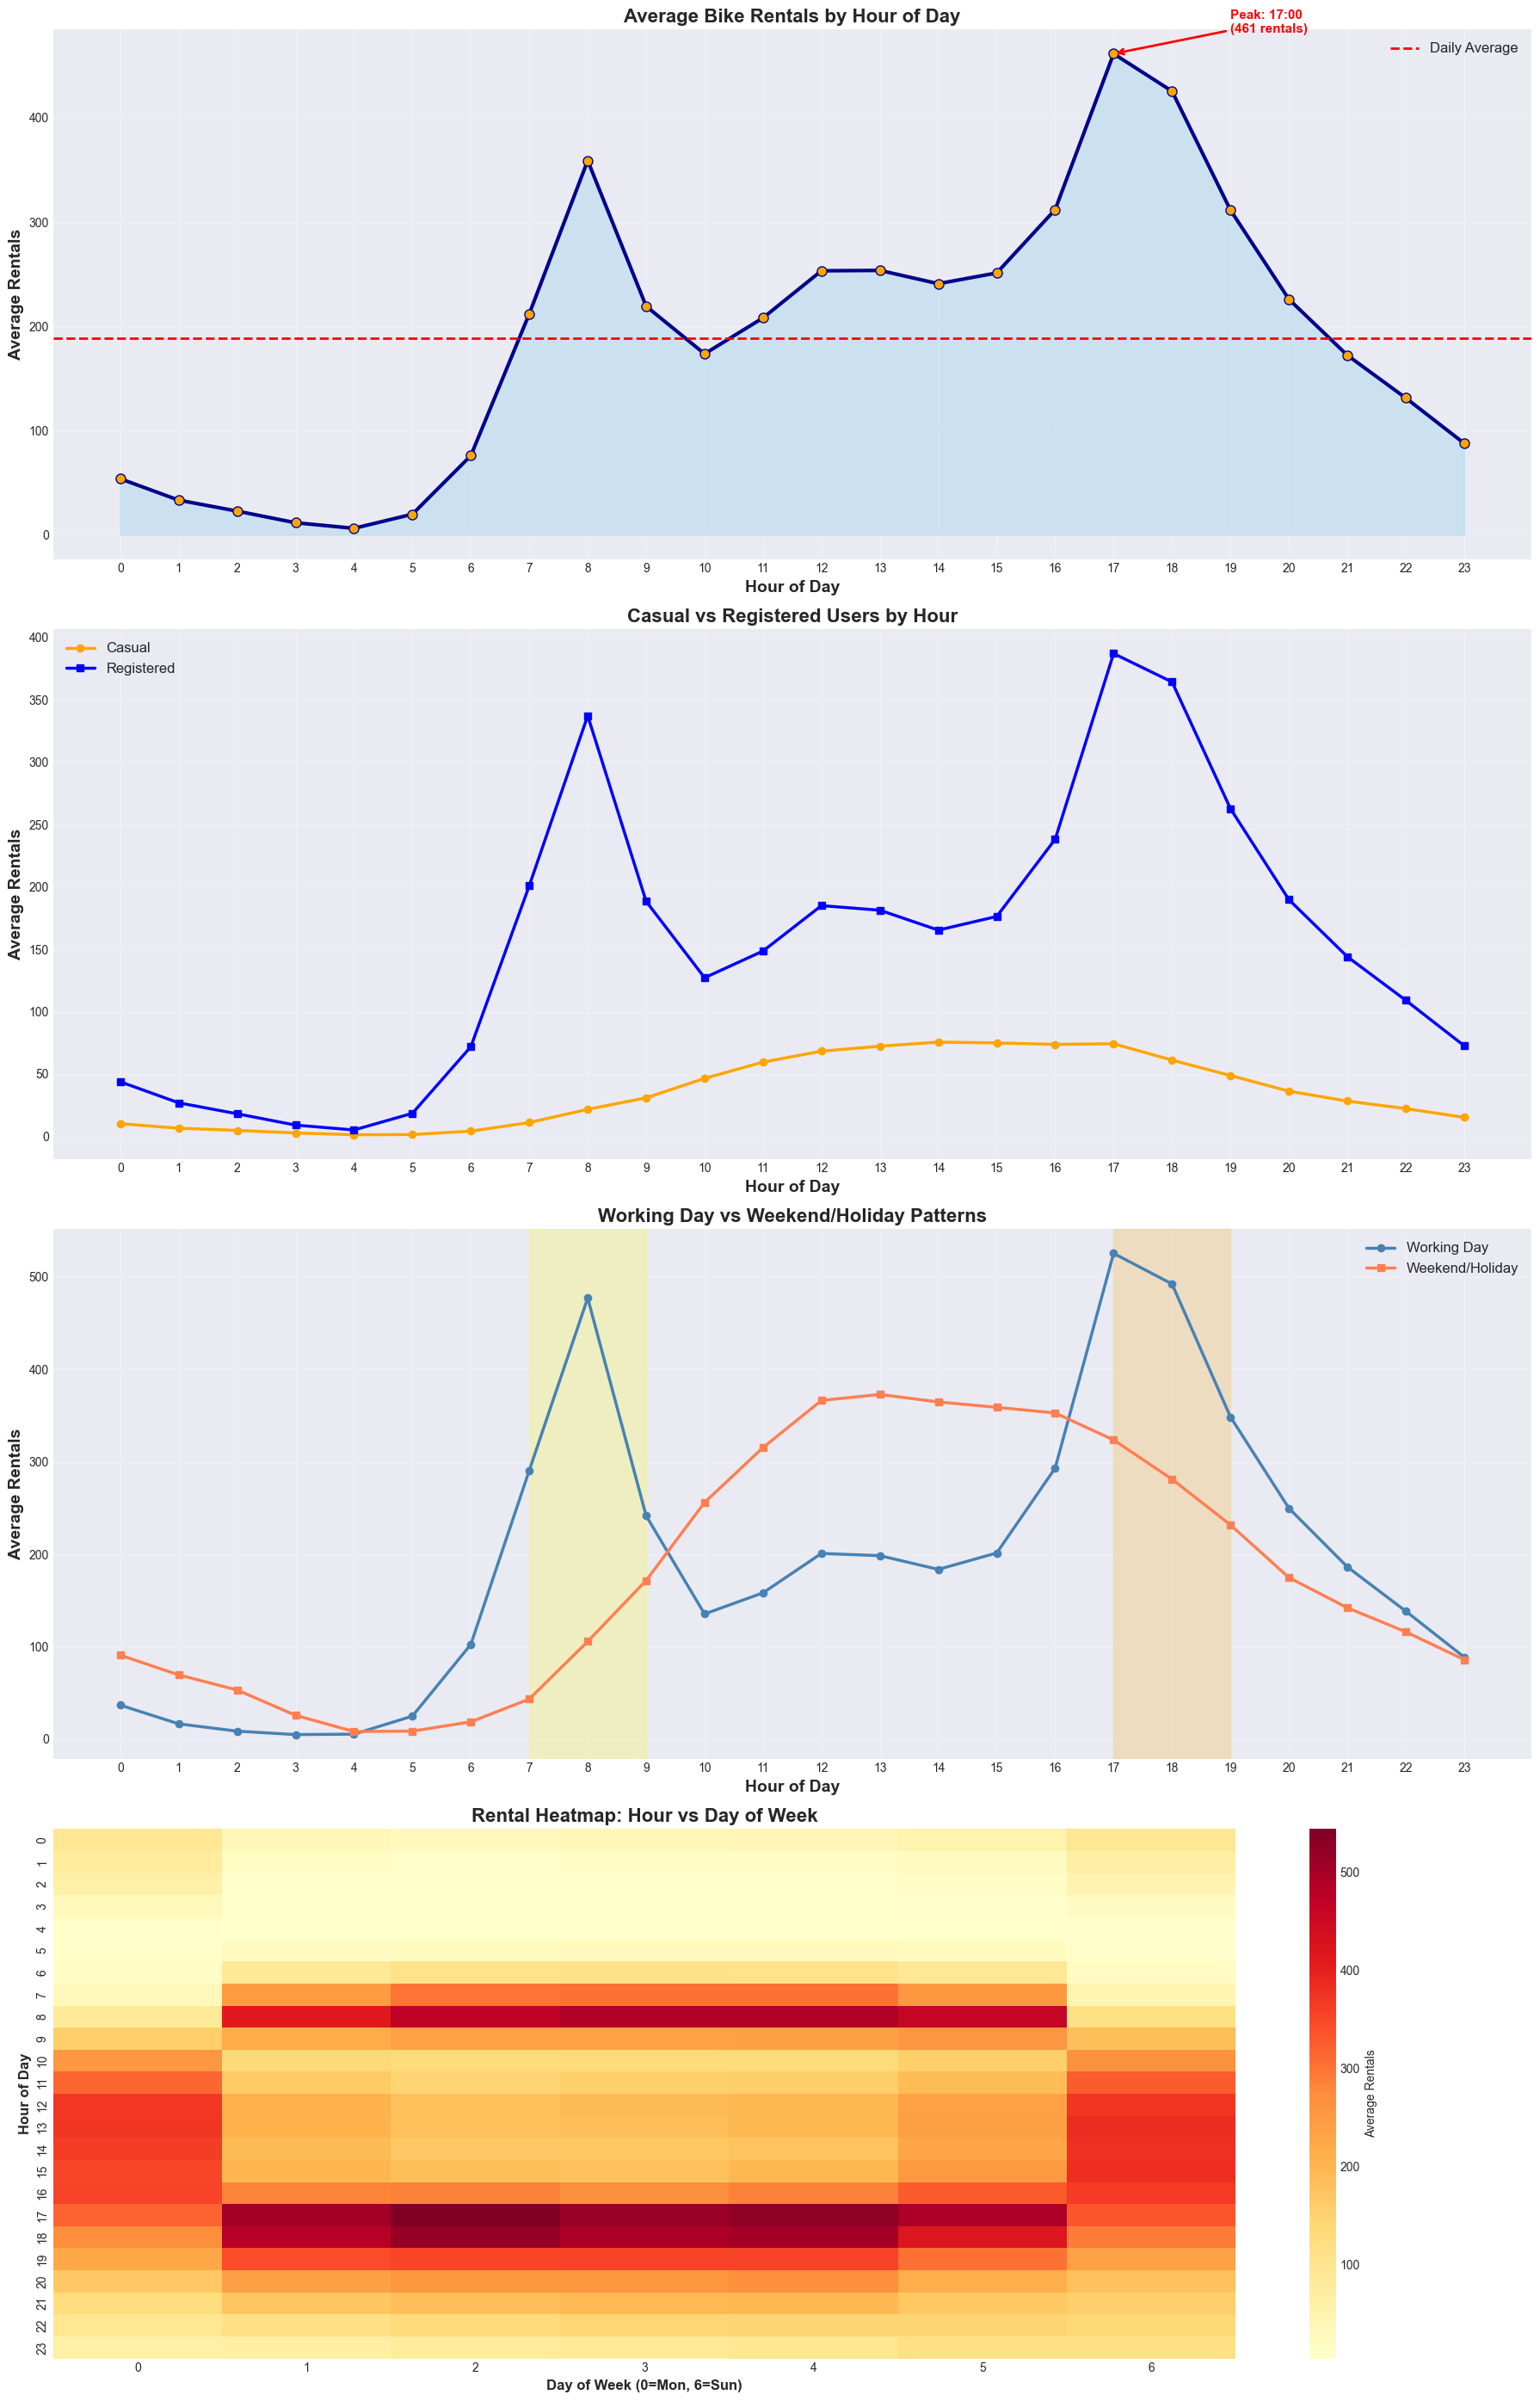


HOURLY PATTERN INSIGHTS

Peak Hour: 17:00 (461 average rentals)
Lowest Hour: 4:00 (6 average rentals)
Peak/Lowest Ratio: 72.6x

Morning Rush (7-9 AM): 336 avg on working days
Evening Rush (5-7 PM): 455 avg on working days


In [ ]:
# Analyze hourly patterns (overall, casual vs registered, working vs non-working, heatmap) and print insights.
fig, axes = plt.subplots(4, 1, figsize=(18, 28))  # 4 rows, 1 column

# ---------------------------------------------------------
# 1️⃣ Average rentals by hour of day
# ---------------------------------------------------------
hourly_avg = df_hour.groupby('hr')['cnt'].mean()
axes[0].plot(hourly_avg.index, hourly_avg.values, marker='o', linewidth=3,
             markersize=8, color='darkblue', markerfacecolor='orange')
axes[0].fill_between(hourly_avg.index, hourly_avg.values, alpha=0.3, color='skyblue')
axes[0].set_xlabel('Hour of Day', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Average Rentals', fontsize=14, fontweight='bold')
axes[0].set_title('Average Bike Rentals by Hour of Day', fontsize=16, fontweight='bold')
axes[0].set_xticks(range(0, 24))
axes[0].grid(True, alpha=0.3)

axes[0].axhline(y=hourly_avg.mean(), color='red', linestyle='--', linewidth=2, label='Daily Average')
axes[0].legend(fontsize=12)

# Annotate peak hour
peak_hour = hourly_avg.idxmax()
axes[0].annotate(f'Peak: {peak_hour}:00\n({hourly_avg.max():.0f} rentals)',
                 xy=(peak_hour, hourly_avg.max()),
                 xytext=(peak_hour+2, hourly_avg.max()+20),
                 arrowprops=dict(arrowstyle='->', color='red', lw=2),
                 fontsize=11, fontweight='bold', color='red')


# ---------------------------------------------------------
# 2️⃣ Casual vs Registered by hour
# ---------------------------------------------------------
hourly_users = df_hour.groupby('hr')[['casual', 'registered']].mean()

axes[1].plot(hourly_users.index, hourly_users['casual'], marker='o', linewidth=2.5,
             label='Casual', color='orange', markersize=6)
axes[1].plot(hourly_users.index, hourly_users['registered'], marker='s', linewidth=2.5,
             label='Registered', color='blue', markersize=6)

axes[1].set_xlabel('Hour of Day', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average Rentals', fontsize=14, fontweight='bold')
axes[1].set_title('Casual vs Registered Users by Hour', fontsize=16, fontweight='bold')
axes[1].set_xticks(range(0, 24))
axes[1].legend(fontsize=12, loc='upper left')
axes[1].grid(True, alpha=0.3)


# ---------------------------------------------------------
# 3️⃣ Working Day vs Non-working Day Patterns
# ---------------------------------------------------------
working_hourly = df_hour[df_hour['workingday'] == 1].groupby('hr')['cnt'].mean()
non_working_hourly = df_hour[df_hour['workingday'] == 0].groupby('hr')['cnt'].mean()

axes[2].plot(working_hourly.index, working_hourly.values, marker='o', linewidth=2.5,
             label='Working Day', color='steelblue', markersize=6)
axes[2].plot(non_working_hourly.index, non_working_hourly.values, marker='s', linewidth=2.5,
             label='Weekend/Holiday', color='coral', markersize=6)

axes[2].set_xlabel('Hour of Day', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Average Rentals', fontsize=14, fontweight='bold')
axes[2].set_title('Working Day vs Weekend/Holiday Patterns', fontsize=16, fontweight='bold')
axes[2].set_xticks(range(0, 24))
axes[2].legend(fontsize=12)
axes[2].grid(True, alpha=0.3)

# Highlight commute hours
axes[2].axvspan(7, 9, alpha=0.2, color='yellow', label='Morning Commute')
axes[2].axvspan(17, 19, alpha=0.2, color='orange', label='Evening Commute')


# ---------------------------------------------------------
# 4️⃣ Heatmap — Hour vs Weekday
# ---------------------------------------------------------
hour_weekday_pivot = df_hour.pivot_table(values='cnt', index='hr', columns='weekday', aggfunc='mean')

sns.heatmap(hour_weekday_pivot, cmap='YlOrRd', annot=False, fmt='.0f',
            cbar_kws={'label': 'Average Rentals'}, ax=axes[3])

axes[3].set_xlabel('Day of Week (0=Mon, 6=Sun)', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Hour of Day', fontsize=12, fontweight='bold')
axes[3].set_title('Rental Heatmap: Hour vs Day of Week', fontsize=16, fontweight='bold')


plt.tight_layout()
plt.show()


# ------------------- PRINT INSIGHTS -------------------
print("\n" + "="*80)
print("HOURLY PATTERN INSIGHTS")
print("="*80)
print(f"\nPeak Hour: {hourly_avg.idxmax()}:00 ({hourly_avg.max():.0f} average rentals)")
print(f"Lowest Hour: {hourly_avg.idxmin()}:00 ({hourly_avg.min():.0f} average rentals)")
print(f"Peak/Lowest Ratio: {hourly_avg.max()/hourly_avg.min():.1f}x")
print(f"\nMorning Rush (7-9 AM): {working_hourly[7:10].mean():.0f} avg on working days")
print(f"Evening Rush (5-7 PM): {working_hourly[17:20].mean():.0f} avg on working days")


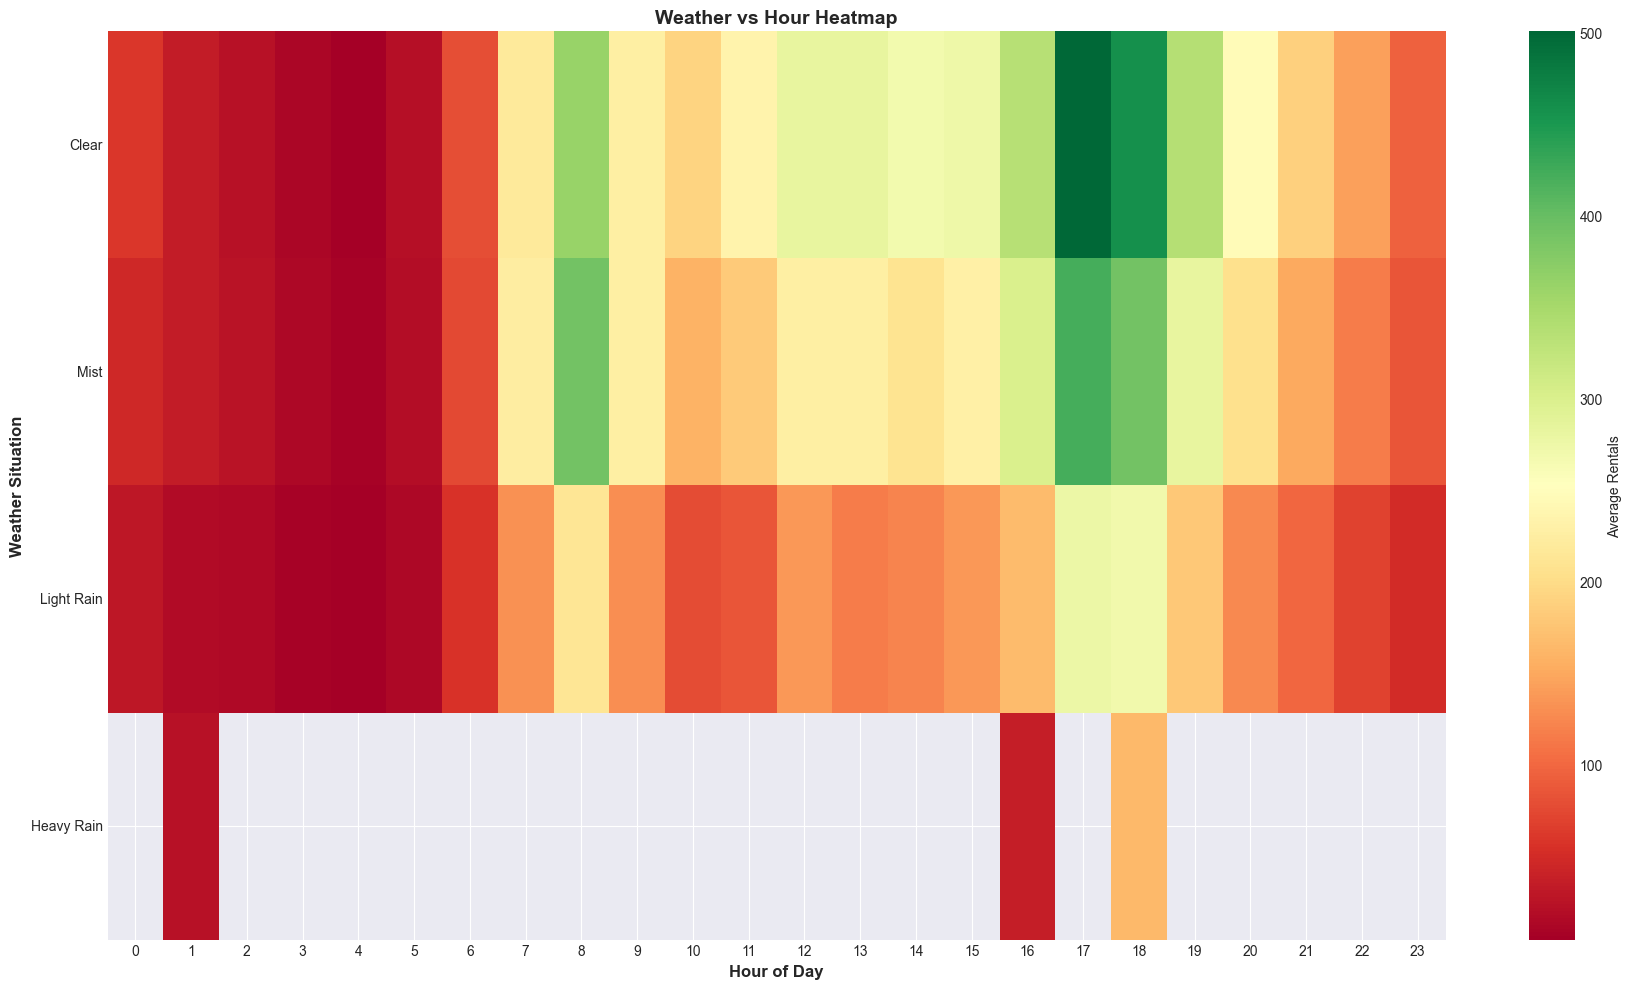

In [ ]:
#Heatmap of rentals by hour and weather situation.
fig, ax = plt.subplots(1, 1, figsize=(18, 10))  # Single graph

# Weather vs Hour Heatmap
weather_hour_pivot = df_hour.pivot_table(values='cnt', index='weathersit',
                                         columns='hr', aggfunc='mean')

sns.heatmap(weather_hour_pivot, cmap='RdYlGn', annot=False,
            cbar_kws={'label': 'Average Rentals'}, ax=ax)

ax.set_xlabel('Hour of Day', fontsize=12, fontweight='bold')
ax.set_ylabel('Weather Situation', fontsize=12, fontweight='bold')
ax.set_title('Weather vs Hour Heatmap', fontsize=14, fontweight='bold')
ax.set_yticklabels(['Clear', 'Mist', 'Light Rain', 'Heavy Rain'], rotation=0)

plt.tight_layout()
plt.show()


In [13]:
# 8. COMPREHENSIVE HOURLY SUMMARY STATISTICS
print("\n" + "="*80)
print("COMPREHENSIVE HOURLY DATA SUMMARY")
print("="*80)

print("\n OVERALL STATISTICS:")
print(f"Total Records: {len(df_hour):,}")
print(f"Total Rentals: {df_hour['cnt'].sum():,}")
print(f"Average Hourly Rentals: {df_hour['cnt'].mean():.2f}")
print(f"Median Hourly Rentals: {df_hour['cnt'].median():.0f}")
print(f"Max Hourly Rentals: {df_hour['cnt'].max()}")
print(f"Min Hourly Rentals: {df_hour['cnt'].min()}")
print(f"Standard Deviation: {df_hour['cnt'].std():.2f}")

print("\nPEAK HOURS:")
hourly_avg = df_hour.groupby('hr')['cnt'].mean()
print(f"Overall Peak Hour: {hourly_avg.idxmax()}:00 ({hourly_avg.max():.0f} avg rentals)")
print(f"Lowest Hour: {hourly_avg.idxmin()}:00 ({hourly_avg.min():.0f} avg rentals)")
#print(f"Peak/Lowest Ratio: {hourly_avg.max()/hourly_avg.min():.1f}x difference")

print("\n" + "="*80)


COMPREHENSIVE HOURLY DATA SUMMARY

 OVERALL STATISTICS:
Total Records: 17,379
Total Rentals: 3,292,679
Average Hourly Rentals: 189.46
Median Hourly Rentals: 142
Max Hourly Rentals: 977
Min Hourly Rentals: 1
Standard Deviation: 181.39

PEAK HOURS:
Overall Peak Hour: 17:00 (461 avg rentals)
Lowest Hour: 4:00 (6 avg rentals)

